In [ ]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

In [21]:
import sys
if IN_COLAB:
    !git clone -q https://github.com/sbeeredd04/sandbox.git
    !pip install -q --progress-bar off jaxtyping open_clip_torch omegaconf
    sys.path.insert(0, "sandbox/token-opt")
    sys.path.insert(0, "sandbox/continuous-tokenizer")
else:
    sys.path.insert(0, "..")

fatal: destination path 'sandbox' already exists and is not an empty directory.


In [18]:
import os
# Set this environment for deterministic execution
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

In [19]:
import torch
# Enable for deterministic algorithms
torch.use_deterministic_algorithms(True, warn_only=False)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

from pathlib import Path
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.v2 as v2
import torchvision.transforms.v2.functional as tvf
from torchvision.datasets import ImageNet
from einops import rearrange

In [23]:
from tto.test_time_opt import (
    TestTimeOpt,
    TestTimeOptConfig,
    CLIPObjective,
)

/content/sandbox/continuous_tokenizer/modelling/modules/timm_vit/vision_transformer.py:2186: UserWarning: Overwriting vit_tiny_patch16_224 in registry with modelling.modules.timm_vit.vision_transformer.vit_tiny_patch16_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/sandbox/continuous_tokenizer/modelling/modules/timm_vit/vision_transformer.py:2205: UserWarning: Overwriting vit_tiny_patch16_384 in registry with modelling.modules.timm_vit.vision_transformer.vit_tiny_patch16_384. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/sandbox/continuous_tokenizer/modelling/modules/timm_vit/vision_transformer.py:2214: UserWarning: Overwriting vit_small_patch32_224 in registry with modelling.modules.timm_vit.vision_transformer.vit_small_patch32_224. This is because the name being registered conflicts with an exis

In [ ]:
#config variables
gpus = "8,9"

In [24]:
device = torch.device("cuda")

## Utils

In [25]:
def load_img(path, device=None):
    if IN_COLAB:
        path = "./token-opt/notebooks" / Path(path)
    img = (1. / 255.) * torch.from_numpy(
        np.array(Image.open(path)).astype(np.float32)
    ).permute(2, 0, 1)
    img = tvf.resize(img, 256)
    img = tvf.center_crop(img, 256)
    img = img.unsqueeze(0)
    if device is not None:
        img = img.to(device)
    return img

def display_image(*tensors):
    tensors = [255. * t.squeeze() for t in tensors]
    img = Image.fromarray(rearrange(
        tensors, "b c h w -> h (b w) c"
    ).to("cpu", dtype=torch.uint8).numpy())
    display(img)

def opt_callback(info):
    if info.i % 50 == 0:
        print(f"i = {info.i}")
        print("  CLIP score =", "\t".join(
            map(lambda l: f"{-l:.3f}", info.loss))
        )
        imgs = tto.decode(info.tokens).clamp(0., 1.)
        display_image(*imgs)

# Set up the objective function

In [26]:
# Use CLIP similarity maximization objective
objective = CLIPObjective(num_augmentations=8, cfg_scale=1.2)

# Set prompt
objective.prompt = [
    "a photo of a tiger",
    "a photo of a husky",
    "a photo of a sparrow",
]

# Optionally set a negative prompt
# Note: also need to set cfg_scale > 1 in CLIPObjective if using this!
objective.neg_prompt = "bad, low-res, unnatural"

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

# Configure test time optimization

In [27]:
tto_config = TestTimeOptConfig(
    num_iter=301,
    ema_decay=0.98,
    lr=1e-1,
    enable_amp=True,
    reg_weight=0.025,
    #token_noise=1e-3,
    reg_type="seed",
)
tto = TestTimeOpt(tto_config, objective).to(device)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.56G [00:00<?, ?B/s]

# Load seed images

In [28]:
# Load seed image
img = torch.cat([
    load_img("ILSVRC2012_val_00008636.png", device),
    load_img("ILSVRC2012_val_00008636.png", device),
    load_img("ILSVRC2012_val_00010240.png", device),
], dim=0)

# Alternatively, initialize directly from given tokens (e.g. randomly
# sampled), but this is disabled when setting `seed_tokens = None`.
seed_tokens = None

# Run Optimization

In [ ]:
print("Seed")
display_image(*img)

# Run optimization
torch.manual_seed(0)
img_opt = tto(
    seed=img if seed_tokens is None else None,
    seed_tokens=seed_tokens,
    callback=opt_callback
)

# TiTok Token Swapping Experiment

This section demonstrates token swapping between two images using the TiTok model.

In [37]:
import sys
sys.path.insert(0, "..")
from titok.modeling.titok import TiTok
from omegaconf import OmegaConf

# Load TiTok model
def load_titok_model(checkpoint_path, device):
    try:
        # Try loading as Hugging Face model first
        print(f"Attempting to load from Hugging Face: {checkpoint_path}")
        model = TiTok.from_pretrained(checkpoint_path)
        model.eval()
        model.to(device)

        for param in model.parameters():
            param.requires_grad = False

        print(f"✓ Successfully loaded from Hugging Face")
        return model

    except Exception as e:
        print(f"Hugging Face loading failed: {e}")
        print(f"Attempting to load from local path: {checkpoint_path}")

        # Try loading from local path
        config = OmegaConf.load(f"{checkpoint_path}/config.json")
        model = TiTok(config)

        # Load weights
        checkpoint = torch.load(f"{checkpoint_path}/pytorch_model.bin", map_location=device)
        model.load_state_dict(checkpoint, strict=True)
        model.eval()
        model.to(device)

        for param in model.parameters():
            param.requires_grad = False

        print(f"✓ Successfully loaded from local path")
        return model

In [44]:
# Load TiTok model - specify your checkpoint path here
checkpoint_path = "yucornetto/tokenizer_titok_l32_imagenet"  # Update this path
titok_model = load_titok_model(checkpoint_path, device)
print(f"TiTok model loaded successfully")
print(f"Quantize mode: {titok_model.quantize_mode}")
print(f"Number of latent tokens: {titok_model.num_latent_tokens}")

Attempting to load from Hugging Face: yucornetto/tokenizer_titok_l32_imagenet
✓ Successfully loaded from Hugging Face
TiTok model loaded successfully
Quantize mode: vq
Number of latent tokens: 32


In [53]:
def encode_tokens_titok(model, img, quantize=False):
    with torch.no_grad():
        z = model.encoder(pixel_values=img, latent_tokens=model.latent_tokens)

        if quantize:
            if model.quantize_mode == "vq":
                z_quantized, result_dict = model.quantize(z)
                return z_quantized
            else:
                from titok.modeling.quantizer.quantizer import DiagonalGaussianDistribution
                posteriors = DiagonalGaussianDistribution(z)
                z_quantized = posteriors.sample()
                return z_quantized

        return z


def decode_tokens_titok(model, tokens, quantize=False):
    with torch.no_grad():
        if not quantize:
            if model.quantize_mode == "vq":
                tokens_quantized, result_dict = model.quantize(tokens)
                tokens = tokens_quantized
            else:
                from titok.modeling.quantizer.quantizer import DiagonalGaussianDistribution
                posteriors = DiagonalGaussianDistribution(tokens)
                tokens = posteriors.sample()

        img = model.decode(tokens)
        return img


def swap_single_token(base_tokens, source_tokens, token_idx):
    result = base_tokens.clone()
    result[:, :, :, token_idx] = source_tokens[:, :, :, token_idx].clone()
    return result

Tokens batch shape: torch.Size([2, 12, 1, 32])
Batch size: 2
Number of latent tokens: 32

Original Images - Pair 1:


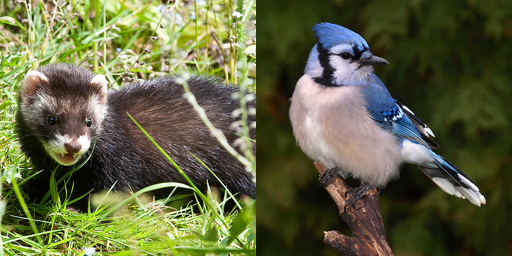

Original Images - Pair 2:


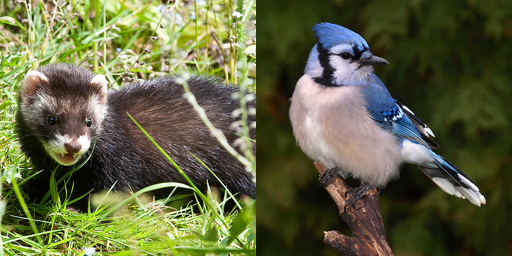

In [54]:
# Set whether to quantize tokens
quantize_tokens = True

# Load four images for two pairs of token swapping
img1_a = load_img("ILSVRC2012_val_00008636.png", device)  # First pair - image A
img1_b = load_img("ILSVRC2012_val_00010240.png", device)  # First pair - image B

img2_a = load_img("ILSVRC2012_val_00008636.png", device)  # Second pair - image A
img2_b = load_img("ILSVRC2012_val_00010240.png", device)  # Second pair - image B

# Concatenate images into batches
img_batch_a = torch.cat([img1_a, img2_a], dim=0)  # Batch of "A" images [2, 3, 256, 256]
img_batch_b = torch.cat([img1_b, img2_b], dim=0)  # Batch of "B" images [2, 3, 256, 256]

# Encode both batches to tokens
tokens_batch_a = encode_tokens_titok(titok_model, img_batch_a, quantize=quantize_tokens)
tokens_batch_b = encode_tokens_titok(titok_model, img_batch_b, quantize=quantize_tokens)

print(f"Tokens batch shape: {tokens_batch_a.shape}")
print(f"Batch size: {tokens_batch_a.shape[0]}")
print(f"Number of latent tokens: {tokens_batch_a.shape[3]}")

# Display original images
print("\n" + "="*60)
print("Original Images - Pair 1:")
display_image(img1_a, img1_b)
print("="*60)
print("Original Images - Pair 2:")
display_image(img2_a, img2_b)
print("="*60)

## Token Swapping Loop

Now we'll swap each token one at a time and visualize the results.

Tokens batch shape: torch.Size([2, 12, 1, 32])
Batch size: 2
Number of latent tokens to swap: 32

Swapping tokens...


Token swapping complete! Swapped 32 tokens

Token swap animation:


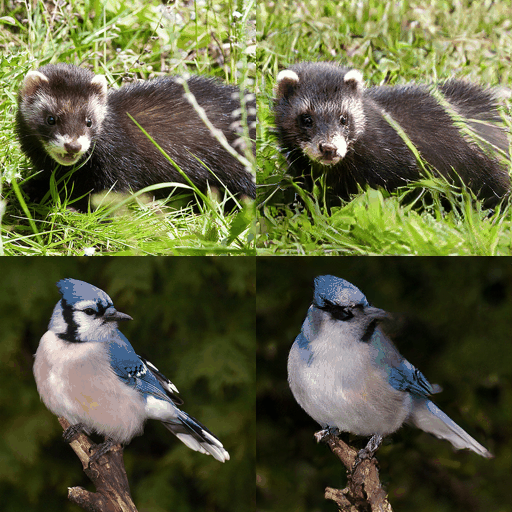

In [64]:
import imageio
from pathlib import Path

def save_img_tensor(tensor, path):
    tensor = tensor.squeeze().clamp(0., 1.) * 255.
    img_array = tensor.permute(1, 2, 0).cpu().to(dtype=torch.uint8).numpy()
    img = Image.fromarray(img_array)
    img.save(path)
    return img_array

def concat_images(img1, img2):
    # Convert to numpy arrays
    img1_np = img1.squeeze().clamp(0., 1.) * 255.
    img1_np = img1_np.permute(1, 2, 0).cpu().to(dtype=torch.uint8).numpy()

    img2_np = img2.squeeze().clamp(0., 1.) * 255.
    img2_np = img2_np.permute(1, 2, 0).cpu().to(dtype=torch.uint8).numpy()

    # Concatenate horizontally
    concat_images = np.concatenate([img1_np, img2_np], axis=1)
    return concat_images

# Create output directory
output_dir = Path("titok_token_swap_frames")
output_dir.mkdir(exist_ok=True)

# Get number of latent tokens
print(f"Tokens batch shape: {tokens_batch_a.shape}")
num_tokens = tokens_batch_a.shape[3]
batch_size = tokens_batch_a.shape[0]
print(f"Batch size: {batch_size}")
print(f"Number of latent tokens to swap: {num_tokens}")
print(f"{'='*60}\n")

# Extract individual tokens for each image
tokens_otter = tokens_batch_a[0:1]
tokens_bird = tokens_batch_b[0:1]

img_otter = img_batch_a[0:1]
img_bird = img_batch_b[0:1]

# Save original images
save_img_tensor(img_otter, output_dir / "original_otter.png")
save_img_tensor(img_bird, output_dir / "original_bird.png")

# Collect frames for GIF
frames = []

print("Swapping tokens...")
print(f"{'='*60}\n")

# Swap each token ONE AT A TIME
for token_idx in range(num_tokens):
    print(f"Token {token_idx + 1}/{num_tokens}...", end="\r")

    # Pair 1: Start with ALL otter tokens, swap ONLY token_idx from bird
    pair1_swapped = swap_single_token(tokens_otter, tokens_bird, token_idx)

    # Pair 2: Start with ALL bird tokens, swap ONLY token_idx from otter
    pair2_swapped = swap_single_token(tokens_bird, tokens_otter, token_idx)

    # Decode both pairs
    img_pair1 = decode_tokens_titok(titok_model, pair1_swapped, quantize=quantize_tokens)
    img_pair2 = decode_tokens_titok(titok_model, pair2_swapped, quantize=quantize_tokens)

    # Create side-by-side images
    pair1_concat = concat_images(img_otter, img_pair1)
    pair2_concat = concat_images(img_bird, img_pair2)

    # Stack both pairs vertically
    combined_frame = np.concatenate([pair1_concat, pair2_concat], axis=0)

    # Save individual frames
    Image.fromarray(pair1_concat).save(output_dir / f"pair1_frame_{token_idx:03d}.png")
    Image.fromarray(pair2_concat).save(output_dir / f"pair2_frame_{token_idx:03d}.png")
    Image.fromarray(combined_frame).save(output_dir / f"combined_frame_{token_idx:03d}.png")

    frames.append(combined_frame)

print(f"\n{'='*60}")
print(f"Token swapping complete! Swapped {num_tokens} tokens")
print(f"{'='*60}\n")

gif_path_combined = output_dir / "token_swap_combined.gif"
imageio.mimsave(gif_path_combined, frames, duration=100000, loop=0)

# Display the combined GIF
print("Token swap animation:")
from IPython.display import Image as IPImage
display(IPImage(filename=str(gif_path_combined)))